In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer

In [53]:
from sklearn.cluster  import KMeans

In [3]:
df = pd.read_csv('data.csv')
df.head()

,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,38,Female,99342,90,3,24,Groceries,113.53
1,2,21,Female,78852,60,2,42,Sports,41.93
2,3,60,Female,126573,30,2,28,Clothing,424.36
3,4,40,Other,47099,74,9,5,Home & Garden,991.93
4,5,65,Female,140621,21,3,25,Electronics,347.08


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    1000 non-null   int64  
 1   age                   1000 non-null   int64  
 2   gender                1000 non-null   str    
 3   income                1000 non-null   int64  
 4   spending_score        1000 non-null   int64  
 5   membership_years      1000 non-null   int64  
 6   purchase_frequency    1000 non-null   int64  
 7   preferred_category    1000 non-null   str    
 8   last_purchase_amount  1000 non-null   float64
dtypes: float64(1), int64(6), str(2)
memory usage: 84.5 KB


In [5]:
df.describe()

,id,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,43.783000,88500.800000,50.685000,5.46900,26.596000,492.348670
std,288.819436,15.042213,34230.771122,28.955175,2.85573,14.243654,295.744253
min,1.000000,18.000000,30004.000000,1.000000,1.00000,1.000000,10.400000
25%,250.750000,30.000000,57911.750000,26.000000,3.00000,15.000000,218.762500
50%,500.500000,45.000000,87845.500000,50.000000,5.00000,27.000000,491.595000
75%,750.250000,57.000000,116110.250000,76.000000,8.00000,39.000000,747.170000
max,1000.000000,69.000000,149973.000000,100.000000,10.00000,50.000000,999.740000


In [6]:
df.isna().sum()

id                      0
age                     0
gender                  0
income                  0
spending_score          0
membership_years        0
purchase_frequency      0
preferred_category      0
last_purchase_amount    0
dtype: int64

In [7]:
df['gender'].unique()

<ArrowStringArray>
['Female', 'Other', 'Male']
Length: 3, dtype: str

In [8]:
df['preferred_category'].unique()

<ArrowStringArray>
['Groceries', 'Sports', 'Clothing', 'Home & Garden', 'Electronics']
Length: 5, dtype: str

In [9]:
df = df.drop(['id'], axis=1)

### EDA

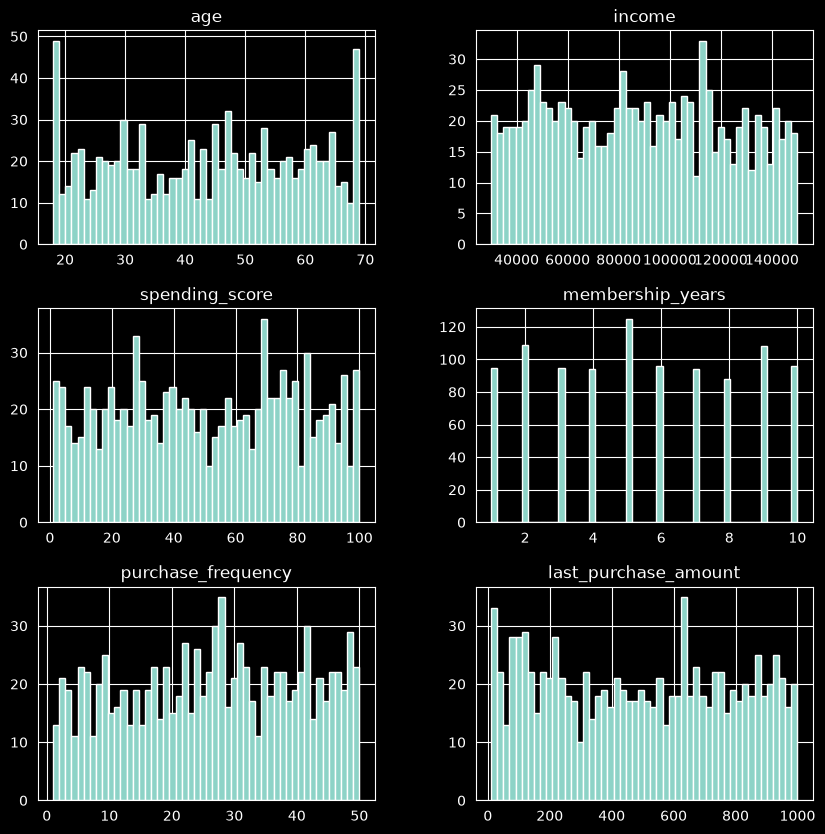

In [10]:
df.hist(figsize=(10,10), bins=50)
plt.show()

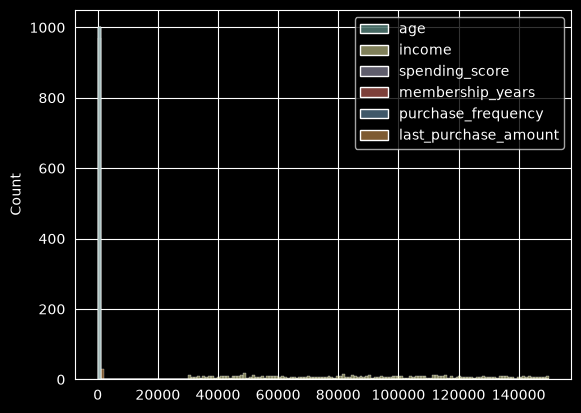

In [11]:
sns.histplot(df)
plt.show()

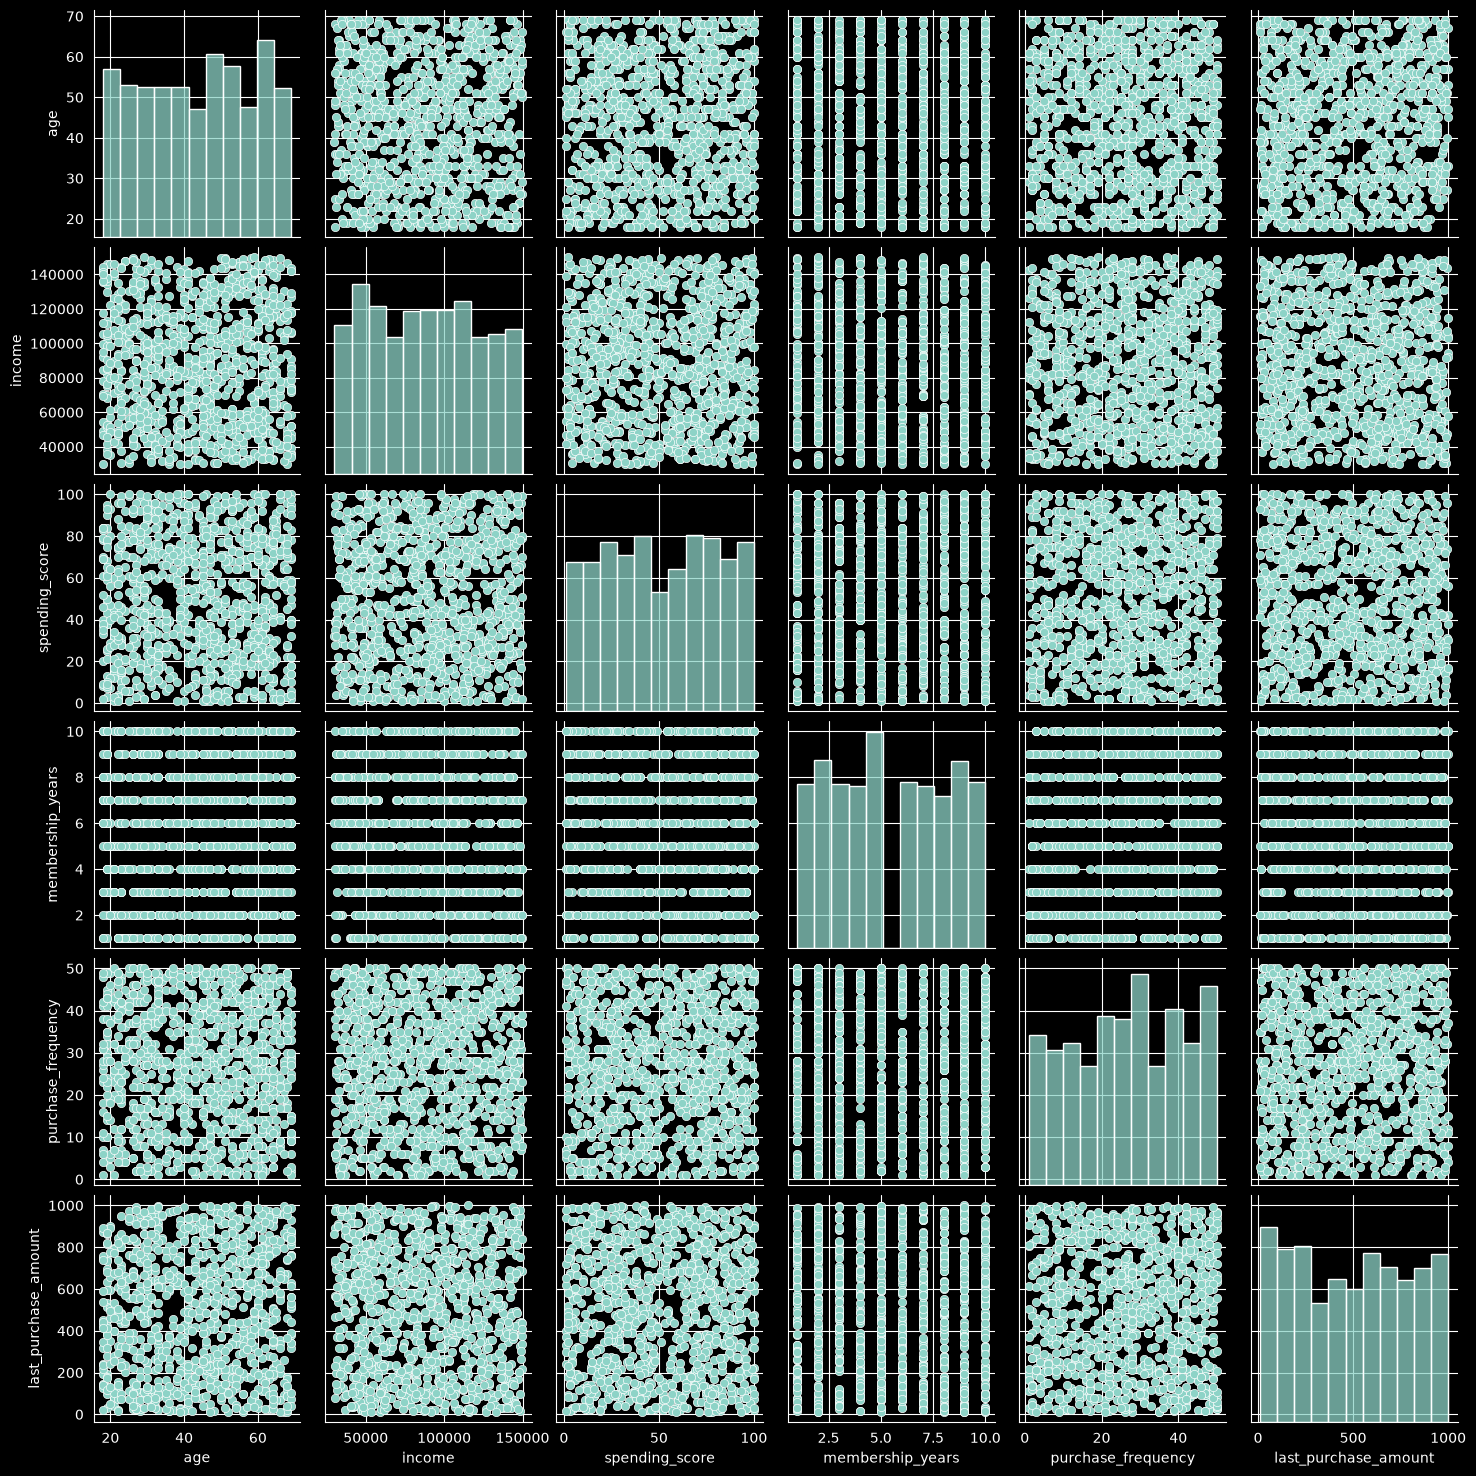

In [12]:
sns.pairplot(df)
plt.show()

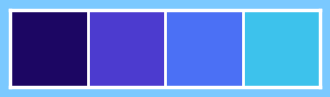

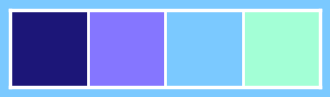

In [39]:
sns.set_style("dark")
sns.set(
    rc={"axes.facecolor":"#2d292e",
        "figure.facecolor":"#7BC9FF"
        })
sns.set_context("poster",font_scale = .7)

palette = ['#1c0663','#4C3BCF','#4B70F5','#3DC2EC']
cluster_palette = ['#1C1678','#8576FF','#7BC9FF','#A3FFD6']
sns.palplot(sns.color_palette(palette))
sns.palplot(sns.color_palette(cluster_palette))

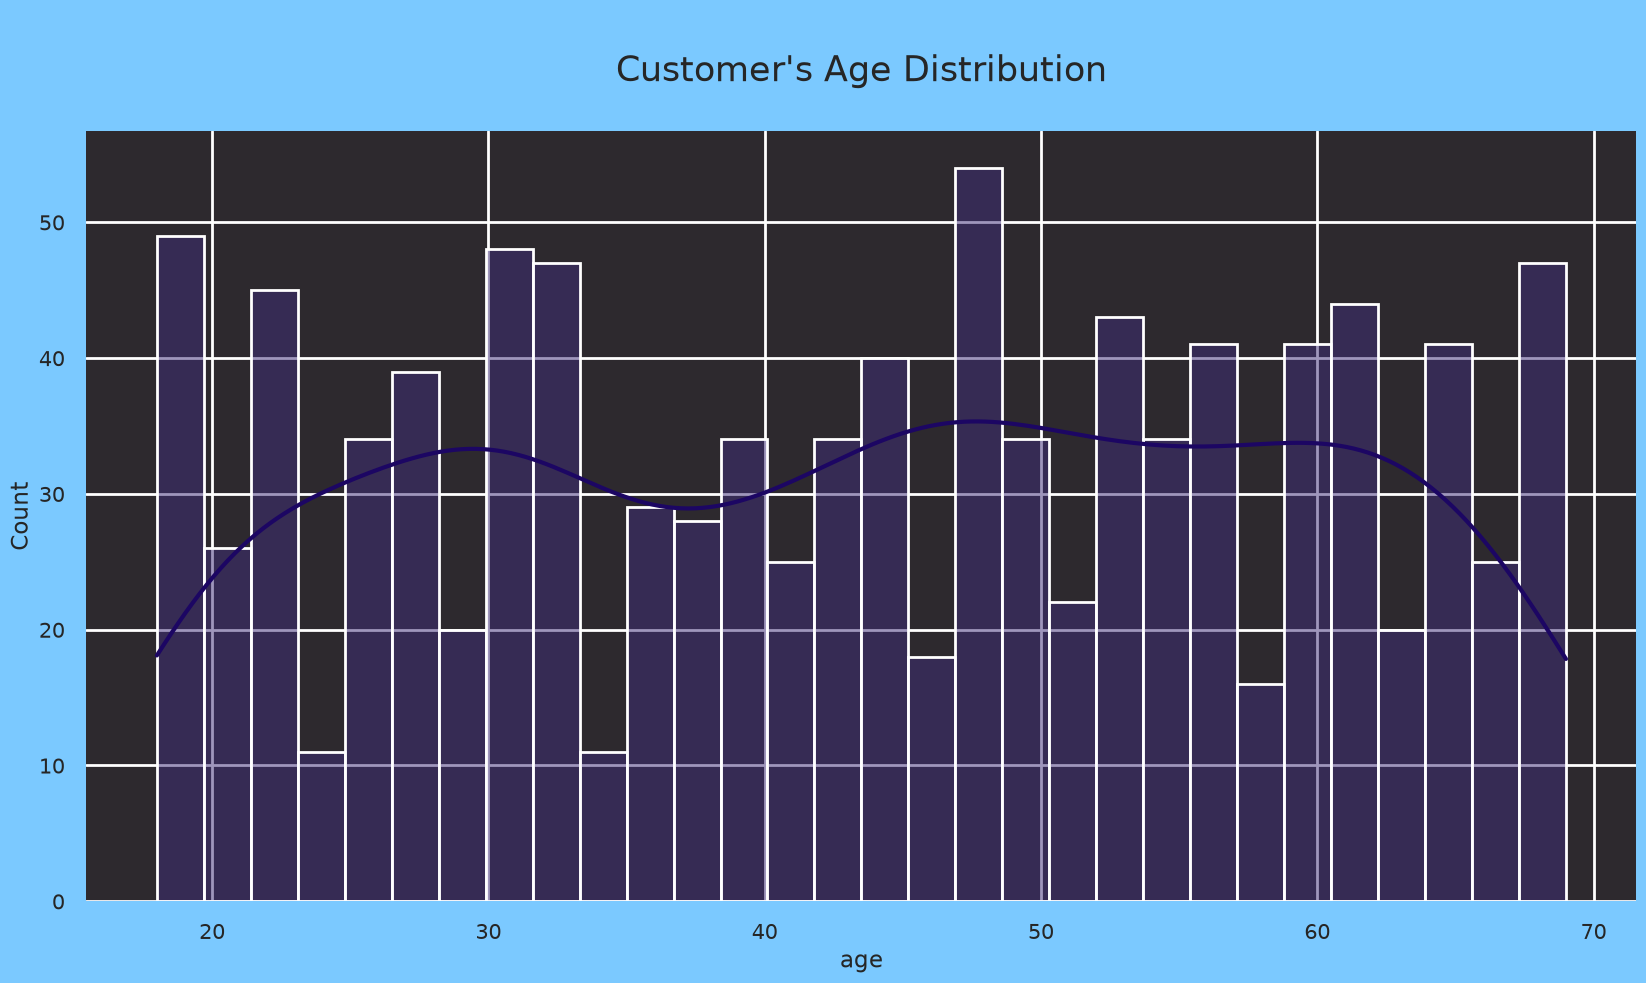

In [40]:
plt.figure(figsize=(20,10))
p = sns.histplot(df['age'], color='#402E7A', kde=True, edgecolor='white', bins=30, alpha=0.5, fill=True)
p.axes.lines[0].set_color(palette[0])
p.axes.set_title("\nCustomer's Age Distribution\n",fontsize=25)
sns.despine(left=True, bottom=True)
plt.show()

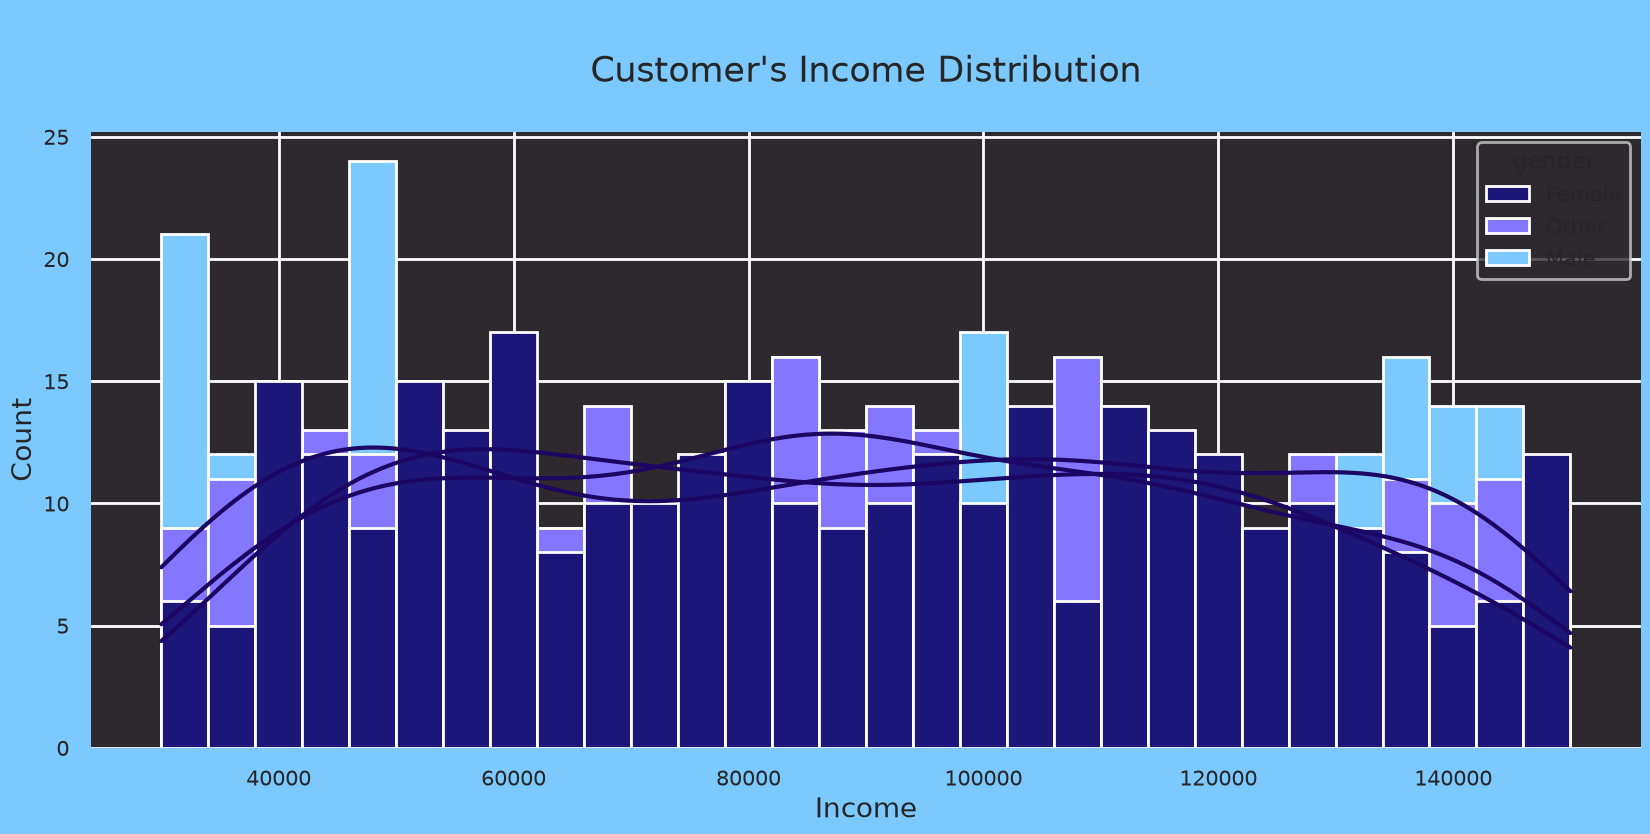

In [41]:
plt.figure(figsize=(20, 8))
p = sns.histplot(data=df, x='income', palette=['#1C1678','#8576FF','#7BC9FF'], kde=True, edgecolor='white', bins=30, alpha=1, fill=True, hue= 'gender')
p.axes.lines[0].set_color(palette[0])
p.axes.lines[1].set_color(palette[0])
p.axes.lines[2].set_color(palette[0])
p.axes.set_title("\nCustomer's Income Distribution\n",fontsize=25)
plt.xlabel('Income', fontsize=20)
plt.ylabel('Count', fontsize=20)
sns.despine(left=True, bottom=True)
plt.show()

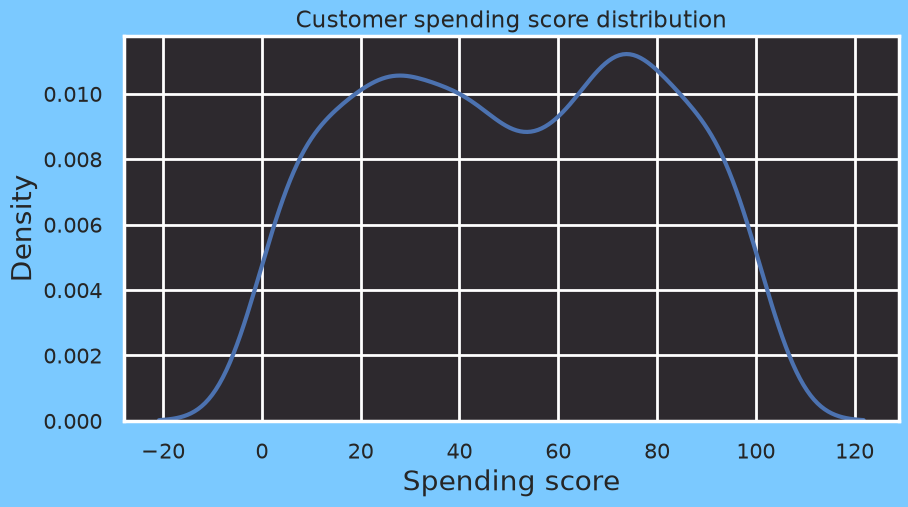

In [42]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df['spending_score'])
plt.title('Customer spending score distribution')
plt.xlabel('Spending score',  fontsize = 20)
plt.ylabel('Density', fontsize= 20)
plt.show()

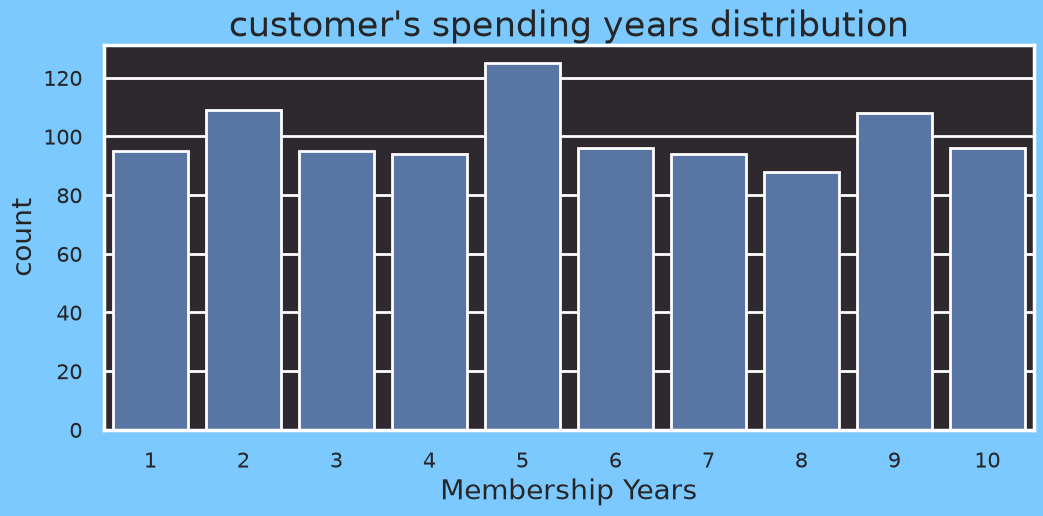

In [43]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='membership_years')
plt.title('customer\'s spending years distribution', fontsize= 25)
plt.xlabel("Membership Years", fontsize= 20)
plt.ylabel('count', fontsize= 20)
plt.show()

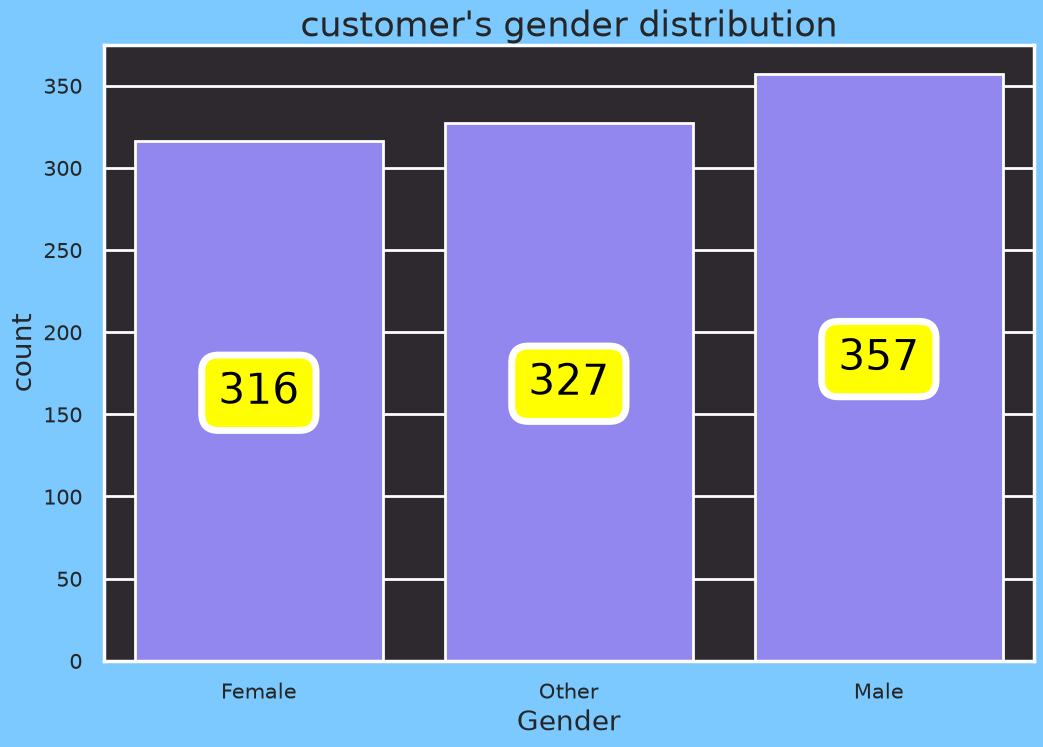

In [44]:
plt.figure(figsize=(12, 8))
p= sns.countplot(data=df, x='gender', color='#8576FF')
plt.title('customer\'s gender distribution', fontsize= 25)
plt.xlabel("Gender", fontsize= 20)
plt.ylabel('count', fontsize= 20)
for container in p.containers:
    p.bar_label(container,label_type="center",padding=6,size=30,color="black",rotation=0,
    bbox={"boxstyle": "round", "pad": 0.4, "facecolor": "yellow", "edgecolor": "white", "linewidth" : 5, "alpha": 1})
plt.show()

### Feature Engineering

In [49]:
cat_ = ['gender', 'preferred_category']
num_ = ['age', 'income', 'spending_score', 'membership_years', 'purchase_frequency', 'last_purchase_amount']

cat_pipeline = make_pipeline(OneHotEncoder(handle_unknown='ignore'))
num_pipeline = make_pipeline(StandardScaler())

preprocessing = ColumnTransformer([
    ('cat', cat_pipeline, cat_),
    ('num', num_pipeline, num_)
])

In [50]:
customer = preprocessing.fit_transform(df)


In [52]:
customer = pd.DataFrame(customer, columns=preprocessing.get_feature_names_out(), index=df.index)
customer.head()
customer.info()
customer.describe()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   cat__gender_Female                     1000 non-null   float64
 1   cat__gender_Male                       1000 non-null   float64
 2   cat__gender_Other                      1000 non-null   float64
 3   cat__preferred_category_Clothing       1000 non-null   float64
 4   cat__preferred_category_Electronics    1000 non-null   float64
 5   cat__preferred_category_Groceries      1000 non-null   float64
 6   cat__preferred_category_Home & Garden  1000 non-null   float64
 7   cat__preferred_category_Sports         1000 non-null   float64
 8   num__age                               1000 non-null   float64
 9   num__income                            1000 non-null   float64
 10  num__spending_score                    1000 non-null   float64
 11  num__membership_

,cat__gender_Female,cat__gender_Male,cat__gender_Other,cat__preferred_category_Clothing,cat__preferred_category_Electronics,cat__preferred_category_Groceries,cat__preferred_category_Home & Garden,cat__preferred_category_Sports,num__age,num__income,num__spending_score,num__membership_years,num__purchase_frequency,num__last_purchase_amount
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,0.316000,0.357000,0.327000,0.170000,0.215000,0.199000,0.206000,0.210000,-7.105427e-17,-8.260059e-17,-7.815970e-17,-1.145750e-16,-1.065814e-17,-9.681145e-17
std,0.465146,0.479355,0.469352,0.375821,0.411028,0.399448,0.404633,0.407512,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.714901e+00,-1.709750e+00,-1.716787e+00,-1.565707e+00,-1.797910e+00,-1.630428e+00
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9.167465e-01,-8.940598e-01,-8.529512e-01,-8.650101e-01,-8.145243e-01,-9.255398e-01
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.094613e-02,-1.915317e-02,-2.366909e-02,-1.643134e-01,2.837770e-02,-2.549659e-03
75%,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.791003e-01,8.069717e-01,8.747199e-01,8.867317e-01,8.712797e-01,8.620585e-01
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.677254e+00,1.796716e+00,1.704002e+00,1.587428e+00,1.643940e+00,1.716501e+00


In [54]:
kmeans = KMeans(n_clusters=5, random_state=42)
pred = kmeans.fit_predict(customer)
customer['predict'] = pred
df['predict'] = customer['predict']

In [55]:
df

,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount,predict
0,38,Female,99342,90,3,24,Groceries,113.53,3
1,21,Female,78852,60,2,42,Sports,41.93,2
2,60,Female,126573,30,2,28,Clothing,424.36,1
3,40,Other,47099,74,9,5,Home & Garden,991.93,3
4,65,Female,140621,21,3,25,Electronics,347.08,1
...,...,...,...,...,...,...,...,...,...
995,57,Male,112170,57,6,1,Clothing,313.64,1
996,23,Other,65337,76,10,23,Groceries,632.83,4
997,23,Male,113097,40,5,42,Sports,75.09,2
998,22,Female,113695,63,7,44,Electronics,505.16,2
